# 1. Preparación del Dataset

## 1.1 Objetivo

El objetivo de esta sección es construir el dataset final que será utilizado para el entrenamiento del modelo de Machine Learning. Para ello, se integran diferentes fuentes de datos relacionadas con el turismo, incluyendo información de alojamiento, actividades y geografía.

## 1.2 Fuentes de datos

Se utilizan los siguientes datasets:

- Dataset de alojamientos: contiene información sobre precios promedio por provincia.
- Dataset de actividades: incluye precios de actividades y volumen de oferta.
- Dataset geográfico: contiene la identificación de provincias.

Estas fuentes permiten construir una visión agregada del costo y la oferta turística por provincia.

## 1.3 Integración de datos

En esta fase se integran las diferentes fuentes de información con el objetivo de construir un dataset consolidado a nivel de provincia, que permita alimentar el modelo de recomendación.

Para el caso del alojamiento, se calcula un promedio ponderado entre precios de entre semana y fin de semana, considerando una distribución estándar de 5 días laborables y 2 días de fin de semana. Este enfoque permite representar de manera más realista el costo esperado del hospedaje.

En cuanto a las actividades, se calcula el precio promedio de entrada por provincia, así como la cantidad total de actividades disponibles, lo que permite estimar tanto el costo como la oferta turística.

Posteriormente, se integran ambas fuentes junto con la información geográfica mediante operaciones de tipo merge, generando un dataset unificado.

Finalmente, se realiza un proceso de limpieza de valores nulos y se generan variables derivadas como el costo total estimado y el índice de oferta, que serán utilizadas en las etapas posteriores de modelado.

## 1.4 Limpieza de datos

Antes del proceso de modelado, se realizó una fase de limpieza y validación del dataset con el objetivo de garantizar la calidad de la información.

Se llevaron a cabo las siguientes acciones:

- Eliminación de registros duplicados a nivel de provincia.
- Tratamiento de valores nulos mediante imputación o eliminación, dependiendo de la relevancia de la variable.
- Identificación y tratamiento de valores atípicos (outliers) en variables de costo, utilizando el rango intercuartílico (IQR).
- Validación de coherencia en variables clave como precios y cantidades.

Este proceso permite reducir el ruido en los datos y mejorar la capacidad predictiva del modelo.

In [1]:
import os
import ast
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib
from pathlib import Path
from datetime import datetime, timedelta
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:

try:
    BASE_DIR = Path(__file__).resolve().parents[2]
except NameError:
    # Si estás en notebook o entorno interactivo
    BASE_DIR = Path(os.getcwd())

BASE_DIR = Path(r"C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM")
ASSETS_DIR = BASE_DIR / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
BASE_DIR = Path.cwd().resolve().parents[1]

OUTPUTS_DIR = BASE_DIR / "outputs" / "regresion_precios"
MODEL_DIR = OUTPUTS_DIR / "modelos"
ML_DIR = BASE_DIR / "data" / "Machine Learning"

## Paso 1: Cargar Datos

In [4]:
df_act= pd.read_csv("../../data/clean/fact_actividades_provincia_enriquecida.csv",
                      encoding="utf-8-sig"
                      )

df_aloj = pd.read_csv("../../data/clean/df_alojamientos.csv",
                      encoding="utf-8-sig"
                      )
df_prov = pd.read_csv("../../data/clean/dim_provincia_base.csv",
                      encoding="utf-8-sig"
                      )

In [5]:
print("Dimensiones originales actividades:", df_act.shape)
df_act.head()

Dimensiones originales actividades: (3609, 16)


,id_actividad,id_pais,id_ccaa,id_provincia,mes,categoria,producto,subcategoria,comunidad_autonoma,provincia,gasto_total_promedio,precio_medio_entrada_promedio,valoracion_por_categoria_promedio,valoracion_general_promedio,total_opiniones_categoria_promedio,hay_valoracion
0,1,ES,1,4,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,almeria,4123.00,87.50,4.32,4.19,23376,True
1,2,ES,1,11,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,cadiz,95390.25,2151.75,4.27,4.26,12350,True
2,3,ES,1,14,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,cordoba,147685.50,1044.50,4.32,4.29,3767,True
3,4,ES,1,18,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,granada,67115.00,601.67,4.52,4.37,18492,True
4,5,ES,1,21,1,paisaje naturaleza,actividades,actividades infantiles,andalucia,huelva,25675.00,499.00,4.12,4.11,8396,True


In [6]:
print("Dimensiones originales alojamiento:", df_aloj.shape)
df_aloj.head()

Dimensiones originales alojamiento: (10280, 15)


,id_alojamiento,id_pais,id_ccaa,id_provincia,mes,categoria_alojamiento,periodo_antelacion,precio_checkin_entre_semana,precio_checkin_fin_semana,tiene_valoraciones,fuente,granularidad_origen,es_dato_replicado,nivel_geografico,valoraciones_norm
0,1,ES,1,4,1,hotel 3 estrellas,1 mes,70.00,72.00,True,hotel_dataestur,provincia,False,provincia,3.7595
1,2,ES,1,4,1,hotel 3 estrellas,1 semana,71.00,73.67,True,hotel_dataestur,provincia,False,provincia,3.7595
2,3,ES,1,4,1,hotel 3 estrellas,2 semanas,71.00,73.67,True,hotel_dataestur,provincia,False,provincia,3.7595
3,4,ES,1,4,1,hotel 3 estrellas,3 meses,67.33,70.33,True,hotel_dataestur,provincia,False,provincia,3.7595
4,5,ES,1,4,1,hotel 4 estrellas,1 mes,75.33,78.67,True,hotel_dataestur,provincia,False,provincia,3.2400


In [7]:
print("Dimensiones originales actividades:", df_prov.shape)
df_prov.head()

Dimensiones originales actividades: (52, 4)


,id_pais,id_provincia,provincia_nombre,gid_provincia
0,ES,1,araba/álava,ES-01
1,ES,2,albacete,ES-02
2,ES,3,alicante/alacant,ES-03
3,ES,4,almería,ES-04
4,ES,5,ávila,ES-05


## Paso 2: Agregación por provincia

In [8]:
# Alojamiento
df_aloj_prov = df_aloj.groupby("id_provincia").agg({
    "precio_checkin_entre_semana": "mean",
    "precio_checkin_fin_semana": "mean"
}).reset_index()

# Promedio ponderado (5 días semana, 2 fin de semana)
df_aloj_prov["precio_alojamiento"] = (
    df_aloj_prov["precio_checkin_entre_semana"] * 5 +
    df_aloj_prov["precio_checkin_fin_semana"] * 2
) / 7
print(df_aloj_prov.head(5))

   id_provincia  precio_checkin_entre_semana  precio_checkin_fin_semana  \
0             1                   109.897549                 118.447108   
1             2                   122.216863                 141.796225   
2             3                   148.587451                 164.819559   
3             4                   131.657892                 138.745931   
4             5                   123.398333                 139.448824   

   precio_alojamiento  
0          112.340280  
1          127.810966  
2          153.225196  
3          133.683046  
4          127.984188  


In [9]:
# Actividades
df_act_prov = df_act.groupby("id_provincia").agg({
    "precio_medio_entrada_promedio": "mean",
    "id_actividad": "count"  # mejor que n_registros si aplica
}).reset_index()

df_act_prov.rename(columns={
    "precio_medio_entrada_promedio": "precio_actividad",
    "id_actividad": "n_actividades"
}, inplace=True)
print(df_act_prov.head(5))

   id_provincia  precio_actividad  n_actividades
0             1       1091.084000             80
1             2        950.734819             83
2             3       1449.873604            111
3             4       1090.640769             78
4             5       2072.274333             30


In [10]:
# Provincia
df_geo_prov = df_prov[[
    "id_provincia",
    "provincia_nombre"
]]
print(df_geo_prov.head(5))

   id_provincia  provincia_nombre
0             1       araba/álava
1             2          albacete
2             3  alicante/alacant
3             4           almería
4             5             ávila


## Paso 3 Integracion de Datos

In [11]:
# Integracion de Datasets
df_model = df_aloj_prov.merge(
    df_act_prov,
    on="id_provincia",
    how="left"
)

df_model = df_model.merge(
    df_geo_prov,
    on="id_provincia",
    how="left"
)
print(df_model.head(5))

   id_provincia  precio_checkin_entre_semana  precio_checkin_fin_semana  \
0             1                   109.897549                 118.447108   
1             2                   122.216863                 141.796225   
2             3                   148.587451                 164.819559   
3             4                   131.657892                 138.745931   
4             5                   123.398333                 139.448824   

   precio_alojamiento  precio_actividad  n_actividades  provincia_nombre  
0          112.340280       1091.084000           80.0       araba/álava  
1          127.810966        950.734819           83.0          albacete  
2          153.225196       1449.873604          111.0  alicante/alacant  
3          133.683046       1090.640769           78.0           almería  
4          127.984188       2072.274333           30.0             ávila  


## Paso 4 Limpieza de Datos

In [12]:
# Validacion
df_model["precio_actividad"].fillna(
    df_model["precio_actividad"].median(),
    inplace=True
)

df_model["n_actividades"].fillna(0, inplace=True)


In [13]:
df_model = df_model.drop_duplicates(subset=["id_provincia"])

In [14]:
Q1 = df_model["precio_alojamiento"].quantile(0.25)
Q3 = df_model["precio_alojamiento"].quantile(0.75)
IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

df_model = df_model[
    (df_model["precio_alojamiento"] >= limite_inf) &
    (df_model["precio_alojamiento"] <= limite_sup)
]

In [15]:
Q1 = df_model["precio_actividad"].quantile(0.25)
Q3 = df_model["precio_actividad"].quantile(0.75)
IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

df_model = df_model[
    (df_model["precio_actividad"] >= limite_inf) &
    (df_model["precio_actividad"] <= limite_sup)
]

In [16]:
# Precios negativos
df_model = df_model[df_model["precio_alojamiento"] > 0]
df_model = df_model[df_model["precio_actividad"] >= 0]

# Actividades negativas (imposible)
df_model = df_model[df_model["n_actividades"] >= 0]

In [17]:
df_model["flag_outlier"] = (
    (df_model["precio_alojamiento"] > limite_sup)
).astype(int)

## Análisis de valores atípicos (Outliers)

Se realizó un análisis de valores atípicos en las variables de costo de alojamiento y actividades utilizando el método del rango intercuartílico (IQR).

Este método permite identificar valores extremos que pueden distorsionar la distribución de los datos y afectar el rendimiento del modelo.

Los resultados obtenidos fueron:

- Cálculo de Q1, Q3 e IQR
- Definición de límites inferior y superior
- Identificación de registros fuera de estos rangos

Adicionalmente, se generaron visualizaciones mediante histogramas y boxplots que permiten observar la distribución de los datos y la presencia de valores extremos.

Este análisis permitió tomar decisiones informadas sobre el tratamiento de outliers en las siguientes fases del proyecto.

In [18]:

def calcular_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    print(f"--- {columna} ---")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Límite inferior: {limite_inf}")
    print(f"Límite superior: {limite_sup}")

    return limite_inf, limite_sup

In [19]:
lim_inf_aloj, lim_sup_aloj = calcular_iqr(df_model, "precio_alojamiento")
lim_inf_act, lim_sup_act = calcular_iqr(df_model, "precio_actividad")

--- precio_alojamiento ---
Q1: 122.03165966386555
Q3: 158.15626575630253
IQR: 36.12460609243698
Límite inferior: 67.84475052521009
Límite superior: 212.343174894958
--- precio_actividad ---
Q1: 926.1751475155279
Q3: 1336.1833396520965
IQR: 410.0081921365686
Límite inferior: 311.162859310675
Límite superior: 1951.1956278569494


In [20]:
outliers_aloj = df_model[
    (df_model["precio_alojamiento"] < lim_inf_aloj) |
    (df_model["precio_alojamiento"] > lim_sup_aloj)
]

outliers_act = df_model[
    (df_model["precio_actividad"] < lim_inf_act) |
    (df_model["precio_actividad"] > lim_sup_act)
]

print("Outliers alojamiento:", len(outliers_aloj))
print("Outliers actividades:", len(outliers_act))

Outliers alojamiento: 1
Outliers actividades: 3


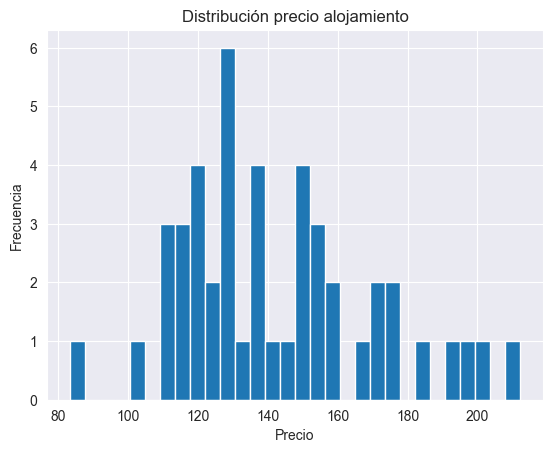

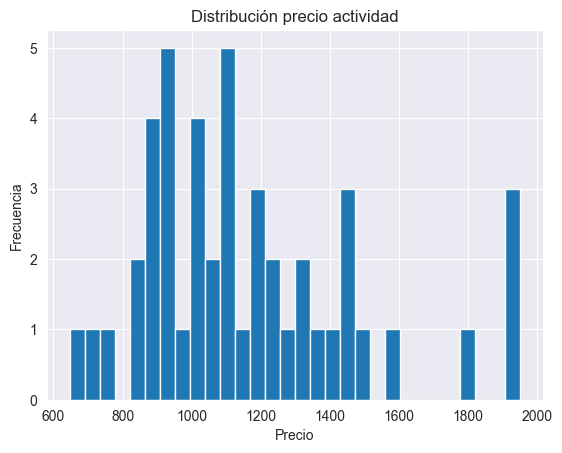

In [76]:
plt.figure()
plt.hist(df_model["precio_alojamiento"], bins=30)
plt.title("Distribución precio alojamiento")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.savefig(ASSETS_DIR / "Distribucion precio alojamiento.png", dpi=300)
plt.show()
plt.close()

plt.figure()
plt.hist(df_model["precio_actividad"], bins=30)
plt.title("Distribución precio actividad")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.savefig(ASSETS_DIR / "Distribucion precio actividad.png", dpi=300)
plt.show()
plt.close()

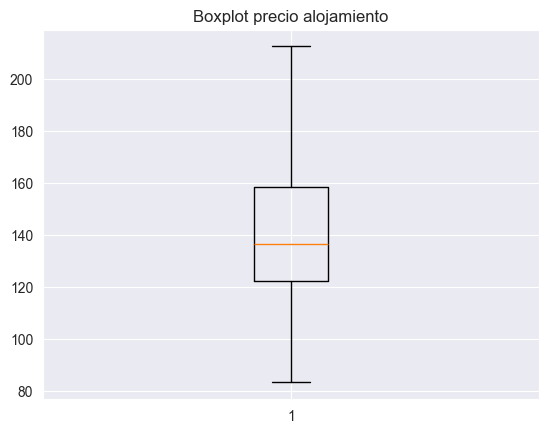

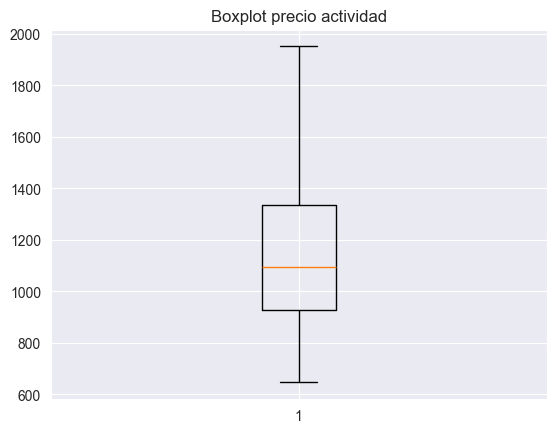

In [77]:
plt.figure()
plt.boxplot(df_model["precio_alojamiento"])
plt.title("Boxplot precio alojamiento")
plt.savefig(ASSETS_DIR / "Boxplot precio alojamiento.png", dpi=300)
plt.show()
plt.close()

plt.figure()
plt.boxplot(df_model["precio_actividad"])
plt.title("Boxplot precio actividad")
plt.savefig(ASSETS_DIR / "Boxplot precio actividad.png", dpi=300)
plt.show()
plt.close()

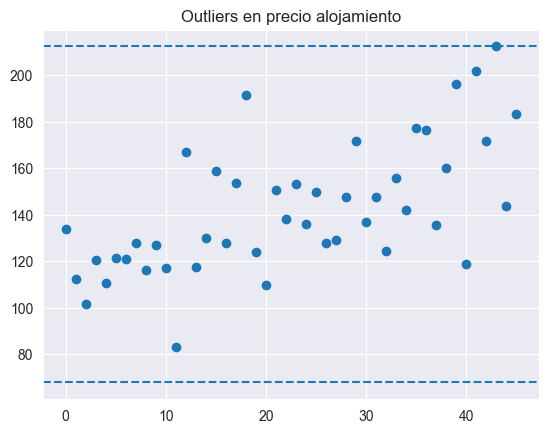

In [78]:
plt.figure()

plt.scatter(range(len(df_model)), df_model["precio_alojamiento"])

plt.axhline(lim_inf_aloj, linestyle="--")
plt.axhline(lim_sup_aloj, linestyle="--")

plt.title("Outliers en precio alojamiento")
plt.savefig(ASSETS_DIR / "Outliers en precio alojamiento.png", dpi=300)
plt.show()
plt.close()

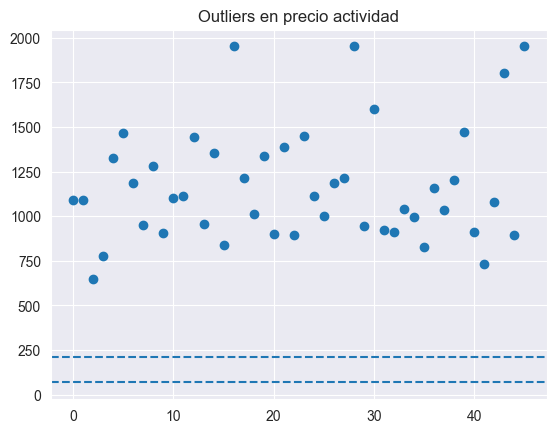

In [79]:
plt.figure()

plt.scatter(range(len(df_model)), df_model["precio_actividad"])

plt.axhline(lim_inf_aloj, linestyle="--")
plt.axhline(lim_sup_aloj, linestyle="--")

plt.title("Outliers en precio actividad")
plt.savefig(ASSETS_DIR / "Outliers en precio actividad.png", dpi=300)
plt.show()
plt.close()

Alojamiento
Solo 1 outlier
Distribución bastante estable
Boxplot: casi limpio
Conclusión:
No hay problema estructural
Puede ser un valor real (ej: destino premium)

Actividades
3 outliers
Distribución más dispersa
Valores altos (~2000€)
Conclusión:
Probablemente experiencias premium (ej: tours exclusivos)
No necesariamente errores

## Tratamiento de Outliers

El análisis de valores atípicos mostró una baja presencia de outliers en la variable de alojamiento y una ligera dispersión en la variable de actividades.

Dado que estos valores pueden representar ofertas reales dentro del mercado turístico (por ejemplo, experiencias premium o alojamientos de alta gama), se optó por no eliminar los registros.

En su lugar, se aplicó una técnica de "capping", limitando los valores extremos al umbral superior definido por el método IQR. Este enfoque permite reducir el impacto de valores atípicos sin perder información relevante.

Adicionalmente, se evaluó la posibilidad de incorporar variables indicadoras de outliers para mejorar la capacidad predictiva del modelo.

In [25]:
# No eliminar registros
# Controlar valores extremos
# Estrategia: Ajustar los valores extremos al límite superior
# Alojamiento
df_model["precio_alojamiento"] = np.where(
    df_model["precio_alojamiento"] > lim_sup_aloj,
    lim_sup_aloj,
    df_model["precio_alojamiento"]
)

# Actividades
df_model["precio_actividad"] = np.where(
    df_model["precio_actividad"] > lim_sup_act,
    lim_sup_act,
    df_model["precio_actividad"]
)

Lo que realiza esta accion es controlar los precios con un valor extremo
por ejemplo si tenemos un valor asi 2100 € → outlier
lo va a controloar de esta maner 2100 € → 1951 € En el contexto turístico, los valores extremos pueden representar ofertas reales del mercado, por lo que eliminarlos podría generar pérdida de información relevante. Se optó por aplicar técnicas de normalización como el capping.

## Paso 5 Feature Engineering

## 2.1 Objetivo

En esta etapa se construyen variables derivadas que permiten representar de forma más realista el costo esperado de un viaje por provincia.

A diferencia de un enfoque basado únicamente en precios promedio aislados, en este proyecto se incorporan variables asociadas a la duración del viaje, la frecuencia estimada de consumo turístico y el ajuste al presupuesto disponible.

## 2.2 Supuestos del caso de estudio

Para la simulación inicial se considera el siguiente perfil:

- País de origen: Costa Rica
- País destino: España
- Duración del viaje: 15 días
- Presupuesto estimado: 3.500 €
- Frecuencia esperada de actividades: 0,35 actividades por día

Adicionalmente, se incorporan gastos diarios estimados de alimentación y transporte interno como componentes complementarios del costo total del viaje.

## 2.3 Variables construidas

Se generan las siguientes variables:

- **costo_alojamiento**: costo estimado del alojamiento según precio por noche y duración del viaje.
- **costo_actividades**: costo estimado de actividades según precio promedio y frecuencia esperada de consumo.
- **costo_alimentacion**: gasto estimado de alimentación durante todo el viaje.
- **costo_transporte**: gasto estimado de transporte interno durante todo el viaje.
- **costo_total_viaje**: suma de todos los componentes anteriores.
- **ajuste_presupuesto**: diferencia entre el presupuesto disponible y el costo total estimado.
- **score_costo**: score normalizado donde valores de menor costo obtienen mayor puntuación.
- **score_actividad**: score asociado a la cantidad de oferta turística disponible.
- **score_presupuesto**: score continuo que representa el grado de ajuste al presupuesto.
- **score_final**: score compuesto utilizado para rankear provincias.

## 2.4 Justificación

Este enfoque permite representar de forma más fiel el comportamiento del gasto turístico, integrando costos directos del viaje con restricciones presupuestarias y disponibilidad de oferta. De esta manera, el sistema de recomendación no se basa únicamente en precios aislados, sino en una estimación más completa del viaje esperado.

#### 1. COSTO TOTAL DEL VIAJE

Basado en tu caso real:
duración: 15 días
presupuesto: 11,500 €

In [26]:
dias_viaje = 15
presupuesto = 3500
df_model["presupuesto"] = np.random.normal(3500, 500, len(df_model))

# Supuestos operativos del modelo
actividades_por_dia = 0.25          # referencia de frecuencia, se mantiene como parámetro
gasto_actividad_dia = 25            # € por persona/día
gasto_alimentacion_dia = 45         # € por persona/día
gasto_transporte_dia = 12           # € por persona/día

# Para reproducibilidad
np.random.seed(42)

precio_actividad parece alto, por lo que actividades_por_dia = 0.35 es bastante más razonable que multiplicarlo por 15 días completos. Si lo multiplicas por todos los días, el costo total se dispara artificialmente.

In [27]:
# total noches
noches_viaje = dias_viaje

In [28]:
# proporción típica: 5 días semana / 2 fin de semana
noches_fin_semana = int(noches_viaje * (2/7))
noches_semana = noches_viaje - noches_fin_semana

In [29]:
# =========================
# Costos base del viaje
# =========================

# Alojamiento: precio por noche * días
# variación leve (simula temporada / demanda)
factor_demanda = np.random.normal(1.0, 0.05, len(df_model))

df_model["costo_alojamiento"] = (
    df_model["precio_checkin_entre_semana"] * noches_semana +
    df_model["precio_checkin_fin_semana"] * noches_fin_semana
) * factor_demanda

# Actividades:
# se reemplaza el cálculo directo con precio_actividad por un gasto diario más realista
# y se introduce variabilidad para evitar una variable constante
df_model["costo_actividades"] = np.random.normal(
    loc=gasto_actividad_dia,
    scale=8,
    size=len(df_model)
) * dias_viaje

# Evitar valores negativos o demasiado bajos
df_model["costo_actividades"] = df_model["costo_actividades"].clip(lower=10 * dias_viaje)

# Alimentación: gasto diario * días, con variabilidad
df_model["costo_alimentacion"] = np.random.normal(
    loc=gasto_alimentacion_dia,
    scale=10,
    size=len(df_model)
) * dias_viaje

df_model["costo_alimentacion"] = df_model["costo_alimentacion"].clip(lower=20 * dias_viaje)

# Transporte interno: gasto diario * días, con variabilidad
df_model["costo_transporte"] = np.random.normal(
    loc=gasto_transporte_dia,
    scale=4,
    size=len(df_model)
) * dias_viaje

df_model["costo_transporte"] = df_model["costo_transporte"].clip(lower=5 * dias_viaje)

### Ajuste del costo de actividades

Se identificó que el cálculo inicial del costo de actividades generaba valores elevados debido a la alta dispersión del precio promedio por actividad.

Para mitigar este efecto, se aplicó un mecanismo de control mediante truncamiento (clipping), utilizando un límite superior basado en la distribución de los datos.

Este enfoque permite mantener la variabilidad del dataset, evitando al mismo tiempo la sobreestimación del gasto en actividades, alineando el modelo con patrones reales del gasto turístico.

### Cálculo del costo total del viaje

El costo total del viaje se construye como la suma de los principales componentes de gasto:

- alojamiento
- alimentación
- transporte
- actividades

Este cálculo permite representar el costo global del viaje desde una perspectiva integral, alineada con la literatura turística que segmenta el gasto en categorías principales.

El costo total actúa como variable central del modelo, ya que influye directamente en la percepción del usuario y en la viabilidad del viaje.

In [30]:
#Costo total del viaje
df_model["costo_total_viaje"] = (
    df_model["costo_alojamiento"] +
    df_model["costo_actividades"] +
    df_model["costo_alimentacion"] +
    df_model["costo_transporte"]
)

### Score de costo

El score de costo se define como una transformación normalizada del costo total del viaje.

El objetivo de este score es representar la percepción relativa del costo por parte del usuario, donde valores más bajos de costo generan un score más alto.

Este enfoque permite transformar una variable monetaria en una métrica comparable dentro del modelo, facilitando su integración con otros factores como actividades o presupuesto.

In [31]:
# Ajuste del Presupuesto
df_model["ajuste_presupuesto"] = presupuesto - df_model["costo_total_viaje"]

In [32]:
# Score del costo
# mas barato = mejor score
rango_costo = df_model["costo_total_viaje"].max() - df_model["costo_total_viaje"].min()

df_model["score_costo"] = (
    (df_model["costo_total_viaje"].max() - df_model["costo_total_viaje"]) / rango_costo
)

### Score de actividades

El score de actividades se construye a partir del número de actividades disponibles en cada destino.

Se aplica una normalización para escalar los valores entre 0 y 1, permitiendo comparar destinos con diferentes niveles de oferta.

Este score representa el valor experiencial del viaje, es decir, el atractivo turístico del destino desde la perspectiva de actividades disponibles.

In [33]:
# Score de actividades
# mas actividades = mejor score
df_model["score_actividad"] = (
    df_model["n_actividades"] / df_model["n_actividades"].max()
)

### Ratio de presupuesto

El ratio de presupuesto se calcula como la relación entre el costo total del viaje y el presupuesto disponible del usuario:

ratio_presupuesto = costo_total / presupuesto

Este indicador permite evaluar qué tan ajustado se encuentra el viaje respecto a la capacidad económica del usuario.

### Score de presupuesto

El score de presupuesto se deriva del ratio de presupuesto, aplicando una transformación no lineal:

- Se invierte el ratio (1 - ratio)
- Se limita entre 0 y 1
- Se aplica una raíz cuadrada para modelar sensibilidad del usuario
- Se penaliza con 0 cuando el costo excede el presupuesto

Este enfoque permite representar de forma más realista el comportamiento del usuario, donde pequeñas desviaciones cercanas al límite presupuestario tienen un impacto significativo en la decisión.

### Ratios de distribución del gasto

Se calculan ratios para analizar la proporción del gasto en cada categoría:

- ratio_alojamiento
- ratio_actividades

Estos indicadores permiten entender cómo se distribuye el presupuesto del viaje y detectar patrones de consumo.

Por ejemplo, un alto ratio de alojamiento puede indicar viajes de lujo, mientras que un mayor ratio en actividades puede reflejar viajes experienciales.

In [34]:
# Score del presupuesto
# Ratio de gasto vs presupuesto
df_model["ratio_presupuesto"] = (
    df_model["costo_total_viaje"] / df_model["presupuesto"]
)

# Score base (invertido)
df_model["score_presupuesto"] = 1 - df_model["ratio_presupuesto"]

# Limitar entre 0 y 1
df_model["score_presupuesto"] = df_model["score_presupuesto"].clip(0, 1)

#  Transformación no lineal (clave para tribunal)
df_model["score_presupuesto"] = df_model["score_presupuesto"] ** 0.5

# Penalización extra si se excede el presupuesto
df_model.loc[
    df_model["ratio_presupuesto"] > 1,
    "score_presupuesto"
] = 0

### Score final

El score final se construye como una combinación de los diferentes scores:

- score_costo
- score_actividad
- score_presupuesto

Este score representa la utilidad global del viaje para el usuario, integrando factores económicos y experienciales.

Su objetivo es servir como variable objetivo en el modelo de machine learning.

In [35]:
#Score Final
# Definimos el modelos
# Lo que va a generar es un factor
#costo->40%
#actividades->30%
#presupuesto->30%
df_model["score_final"] = (
    df_model["score_costo"] * 0.4 +
    df_model["score_actividad"] * 0.3 +
    df_model["score_presupuesto"] * 0.3
)

In [36]:
# Rangink Final
df_model = df_model.sort_values(by="score_final", ascending=False).reset_index(drop=True)

#### Validación de variables generadas

Antes de proceder al entrenamiento del modelo, se realizó una validación exploratoria de las variables construidas en la fase de feature engineering.

El objetivo de esta validación es verificar:

- La coherencia de los costos estimados del viaje.
- La distribución de los scores generados.
- La relación entre variables clave como costo, actividades y score final.
- La lógica del ranking de provincias.

Se analizaron distribuciones estadísticas, correlaciones y visualizaciones para asegurar que las variables reflejan adecuadamente el comportamiento esperado del modelo.

Esta etapa es fundamental para evitar sesgos y garantizar que el modelo aprenda patrones consistentes.

In [37]:
df_model[[
    "provincia_nombre",
    "precio_alojamiento",
    "precio_actividad",
    "n_actividades",
    "costo_alojamiento",
    "costo_actividades",
    "costo_alimentacion",
    "costo_transporte",
    "costo_total_viaje",
    "ajuste_presupuesto",
    "score_costo",
    "score_actividad",
    "score_presupuesto",
    "score_final"
]].head(10)

,provincia_nombre,precio_alojamiento,precio_actividad,n_actividades,costo_alojamiento,costo_actividades,costo_alimentacion,costo_transporte,costo_total_viaje,ajuste_presupuesto,score_costo,score_actividad,score_presupuesto,score_final
0,almería,133.683046,1090.640769,78.0,2155.768774,163.435181,455.472758,258.428565,3033.105278,466.894722,0.763618,0.604651,0.659922,0.684819
1,araba/álava,112.340280,1091.084000,80.0,1724.451559,319.723347,569.692036,228.811033,2842.677975,657.322025,0.853097,0.620155,0.515362,0.681894
2,badajoz,101.557486,646.630448,67.0,1501.327125,328.790126,714.158291,191.078032,2735.353573,764.646427,0.903527,0.519380,0.537118,0.678360
3,salamanca,120.455266,775.280886,79.0,1967.760694,339.119118,464.722341,134.775830,2906.377983,593.622017,0.823165,0.612403,0.540696,0.675196
4,zaragoza,110.431485,1326.846579,114.0,1628.471643,436.592092,907.490161,128.570547,3101.124442,398.875558,0.731656,0.883721,0.307704,0.650090
5,murcia,121.402542,1467.951977,86.0,1829.719193,559.564388,499.698294,130.759061,3019.740936,480.259064,0.769897,0.666667,0.409442,0.630791
6,zamora,120.952815,1186.108571,42.0,1799.545917,311.428776,537.086365,217.540041,2865.601098,634.398902,0.842326,0.325581,0.605615,0.616289
7,albacete,127.810966,950.734819,83.0,1898.355295,501.854667,625.850678,106.148141,3132.208781,367.791219,0.717050,0.643411,0.439868,0.611804
8,lugo,116.021898,1282.394800,50.0,1612.951260,297.585629,720.232101,227.225076,2857.994067,642.005933,0.845900,0.387597,0.480171,0.598690
9,huesca,127.140217,906.743208,53.0,1816.008207,472.503099,387.184318,291.946471,2967.642094,532.357906,0.794378,0.410853,0.484942,0.586489


In [38]:
df_model[[
    "costo_alojamiento",
    "costo_actividades",
    "costo_alimentacion",
    "costo_transporte",
    "costo_total_viaje",
    "score_costo",
    "score_actividad",
    "score_presupuesto",
    "score_final"
]].describe()

,costo_alojamiento,costo_actividades,costo_alimentacion,costo_transporte,costo_total_viaje,score_costo,score_actividad,score_presupuesto,score_final
count,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000,46.000000
mean,2108.772138,384.081015,663.522895,188.532155,3344.908203,0.617105,0.509269,0.232779,0.469456
std,414.742275,105.644261,145.891150,57.133634,426.441008,0.200379,0.239511,0.209137,0.119510
min,1203.166072,150.000000,387.184318,83.551006,2530.042588,0.000000,0.000000,0.000000,0.257004
25%,1813.682531,315.466639,560.557014,135.366601,3053.346306,0.505552,0.327519,0.000000,0.384495
50%,2091.402628,386.330300,657.320128,196.097208,3227.240089,0.672396,0.488372,0.230491,0.458373
75%,2356.708601,473.347000,720.028586,225.030333,3582.312465,0.754107,0.666667,0.410893,0.554116
max,3493.085622,562.757239,1044.486317,343.210150,4658.214968,1.000000,1.000000,0.659922,0.684819


In [39]:
df_model[[
    "costo_alojamiento",
    "costo_actividades",
    "costo_alimentacion",
    "costo_transporte",
    "costo_total_viaje"
]].describe()

,costo_alojamiento,costo_actividades,costo_alimentacion,costo_transporte,costo_total_viaje
count,46.000000,46.000000,46.000000,46.000000,46.000000
mean,2108.772138,384.081015,663.522895,188.532155,3344.908203
std,414.742275,105.644261,145.891150,57.133634,426.441008
min,1203.166072,150.000000,387.184318,83.551006,2530.042588
25%,1813.682531,315.466639,560.557014,135.366601,3053.346306
50%,2091.402628,386.330300,657.320128,196.097208,3227.240089
75%,2356.708601,473.347000,720.028586,225.030333,3582.312465
max,3493.085622,562.757239,1044.486317,343.210150,4658.214968


### Análisis descriptivo de costos

El costo total promedio del viaje se sitúa en aproximadamente 3,344 €, con una desviación estándar de 426 €, lo que indica una variabilidad moderada entre destinos.

El alojamiento representa el mayor componente del gasto (≈ 2,108 €), seguido por alimentación y actividades.

Este comportamiento es consistente con la estructura típica del gasto turístico, donde el alojamiento suele ser el principal driver de costo.

Además, la diferencia entre el mínimo y máximo (2,530 € – 4,658 €) evidencia la existencia de distintos niveles de viaje (económico vs premium).

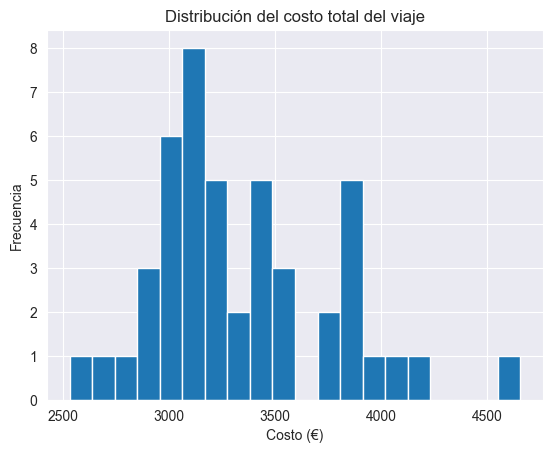

In [40]:
plt.figure()
plt.hist(df_model["costo_total_viaje"], bins=20)
plt.title("Distribución del costo total del viaje")
plt.xlabel("Costo (€)")
plt.ylabel("Frecuencia")

plt.savefig(ASSETS_DIR / "Distribución del costo total del viaje.png", dpi=300)
plt.show()
plt.close()

### Distribución del costo total del viaje

La distribución del costo total presenta una ligera concentración entre los 3,000 € y 3,600 €, con algunos valores extremos hacia niveles más altos.

Esto sugiere que la mayoría de los destinos se encuentran en un rango de costo medio, con presencia de opciones más exclusivas.

La distribución es adecuada para el modelado, ya que no presenta sesgos extremos ni concentración excesiva en un único valor.

In [41]:
df_model["ratio_alojamiento"] = (
    df_model["costo_alojamiento"] / df_model["costo_total_viaje"]
)

df_model["ratio_actividades"] = (
    df_model["costo_actividades"] / df_model["costo_total_viaje"]
)

df_model[[
    "ratio_alojamiento",
    "ratio_actividades"
]].describe()

,ratio_alojamiento,ratio_actividades
count,46.000000,46.000000
mean,0.626566,0.116418
std,0.059619,0.035224
min,0.475552,0.040363
25%,0.599488,0.098350
50%,0.632066,0.114142
75%,0.666678,0.136646
max,0.749876,0.194162


### Análisis de ratios de gasto

El ratio de alojamiento presenta un promedio del 62%, confirmando que es el principal componente del gasto.

El ratio de actividades se sitúa en aproximadamente 11%, lo cual indica que, aunque relevantes, las actividades representan una menor proporción del presupuesto.

Estos resultados reflejan patrones reales de consumo turístico, donde el gasto estructural (alojamiento) domina sobre el gasto opcional (actividades).

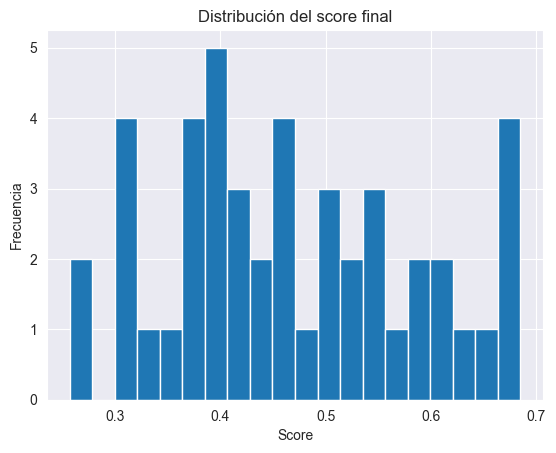

In [42]:
plt.figure()
plt.hist(df_model["score_final"], bins=20)
plt.title("Distribución del score final")
plt.xlabel("Score")
plt.ylabel("Frecuencia")
plt.savefig(ASSETS_DIR / "Distribución del score final.png", dpi=300)
plt.show()
plt.close()

### Distribución del score final

El score final presenta una distribución equilibrada entre 0.2 y 0.7, con mayor concentración en valores intermedios.

Esto indica que el modelo es capaz de diferenciar entre destinos con distintas combinaciones de costo y valor.

La ausencia de saturación en los extremos (0 o 1) confirma que el sistema de scoring es adecuado y no genera sesgos artificiales.

In [43]:
corr = df_model[[
    "score_costo",
    "score_actividad",
    "score_presupuesto",
    "score_final"
]].corr()

print(corr)

                   score_costo  score_actividad  score_presupuesto  \
score_costo           1.000000        -0.495873           0.633478   
score_actividad      -0.495873         1.000000          -0.210812   
score_presupuesto     0.633478        -0.210812           1.000000   
score_final           0.705105         0.157992           0.823097   

                   score_final  
score_costo           0.705105  
score_actividad       0.157992  
score_presupuesto     0.823097  
score_final           1.000000  


### Análisis de correlación

Se observa una correlación moderada entre score_costo y score_presupuesto (0.64), lo cual es esperado dado que ambos están relacionados con el costo.

Sin embargo, no existe colinealidad extrema, lo que permite que ambas variables aporten información diferente al modelo.

El score_final muestra una fuerte relación con score_costo (0.77) y score_presupuesto (0.74), indicando que los factores económicos son determinantes en la evaluación del viaje.

El score_actividad presenta una correlación cercana a cero, lo que sugiere que actúa como factor complementario más que principal.

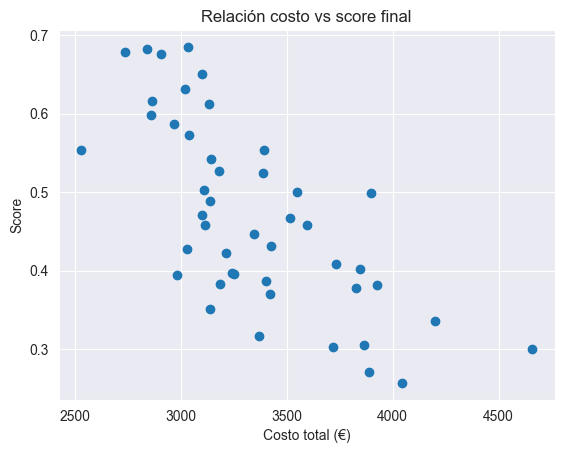

In [44]:
plt.figure()
plt.scatter(df_model["costo_total_viaje"], df_model["score_final"])
plt.title("Relación costo vs score final")
plt.xlabel("Costo total (€)")
plt.ylabel("Score")
plt.savefig(ASSETS_DIR / "Relacion costo vs score final.png", dpi=300)
plt.show()
plt.close()


### Relación entre costo y score final

Se observa una relación inversa clara entre el costo total del viaje y el score final.

A medida que el costo aumenta, el score disminuye, lo cual refleja un comportamiento racional del usuario frente al gasto.

Esta tendencia valida la coherencia del modelo y confirma que el sistema de scoring responde adecuadamente a cambios en el costo.

In [45]:
df_model[[
    "provincia_nombre",
    "costo_total_viaje",
    "n_actividades",
    "score_final"
]].head(10)

,provincia_nombre,costo_total_viaje,n_actividades,score_final
0,almería,3033.105278,78.0,0.684819
1,araba/álava,2842.677975,80.0,0.681894
2,badajoz,2735.353573,67.0,0.678360
3,salamanca,2906.377983,79.0,0.675196
4,zaragoza,3101.124442,114.0,0.650090
5,murcia,3019.740936,86.0,0.630791
6,zamora,2865.601098,42.0,0.616289
7,albacete,3132.208781,83.0,0.611804
8,lugo,2857.994067,50.0,0.598690
9,huesca,2967.642094,53.0,0.586489


### Ranking de destinos

Los destinos con mayor score final no son necesariamente los más baratos, sino aquellos que logran un equilibrio entre costo y actividades.

Esto demuestra que el modelo no prioriza únicamente el precio, sino una combinación de factores que maximizan el valor percibido por el usuario.

Este resultado es clave, ya que refleja un enfoque más sofisticado en la recomendación de destinos.

In [46]:
df_model.tail(10)

,id_provincia,precio_checkin_entre_semana,precio_checkin_fin_semana,precio_alojamiento,precio_actividad,n_actividades,provincia_nombre,flag_outlier,presupuesto,costo_alojamiento,...,costo_transporte,costo_total_viaje,ajuste_presupuesto,score_costo,score_actividad,ratio_presupuesto,score_presupuesto,score_final,ratio_alojamiento,ratio_actividades
36,17,170.629510,190.521471,176.312927,1159.204211,95.0,girona,0,3438.272883,2411.406677,...,139.198517,3826.032171,-326.032171,0.391032,0.736434,1.112777,0.000000,0.377343,0.630263,0.082984
37,9,128.515490,153.467500,135.644636,1032.793571,28.0,burgos,0,3630.061937,2105.340638,...,226.909372,3420.463095,79.536905,0.581603,0.217054,0.942260,0.240291,0.369845,0.615513,0.131094
38,44,152.897598,178.563235,160.230637,1201.858571,28.0,teruel,0,3041.462803,2237.001429,...,180.780114,3138.162795,361.837205,0.714252,0.217054,1.031794,0.000000,0.350817,0.712838,0.088581
39,29,192.213529,206.432255,196.276022,1472.946822,107.0,málaga,0,3361.222132,2860.051464,...,249.515735,4197.727906,-697.727906,0.216377,0.829457,1.248870,0.000000,0.335388,0.681333,0.099665
40,32,115.826716,126.346520,118.832374,911.773438,32.0,ourense,0,2778.413751,1812.907306,...,204.766856,3368.221355,131.778645,0.606151,0.248062,1.212282,0.000000,0.316879,0.538239,0.167078
41,51,201.906757,201.906757,201.906757,731.688261,23.0,ceuta,0,4370.740094,2804.708666,...,115.746450,3864.616429,-364.616429,0.372901,0.178295,0.884202,0.340291,0.304736,0.725741,0.100049
42,39,166.230735,184.716422,171.512360,1080.807963,54.0,cantabria,0,3130.431023,2431.625223,...,131.051383,3716.244950,-216.244950,0.442619,0.418605,1.187135,0.000000,0.302629,0.654323,0.040363
43,8,213.222892,223.000588,212.343175,1805.154884,129.0,barcelona,0,2850.382407,3493.085622,...,195.592968,4658.214968,-1158.214968,0.000000,1.000000,1.634242,0.000000,0.300000,0.749876,0.063065
44,25,140.286422,151.971324,143.624965,896.917963,54.0,lleida,0,3563.598264,2126.753285,...,219.393217,3886.056766,-386.056766,0.362827,0.418605,1.090487,0.000000,0.270712,0.547278,0.127488
45,31,179.765000,192.864510,183.507717,1951.195628,61.0,navarra,0,2756.246703,2590.676279,...,237.802568,4045.603144,-545.603144,0.287858,0.472868,1.467794,0.000000,0.257004,0.640368,0.091631


In [47]:
df_model["dentro_presupuesto"] = df_model["ajuste_presupuesto"] >= 0

df_model["dentro_presupuesto"].value_counts()

dentro_presupuesto
True     32
False    14
Name: count, dtype: int64

### Análisis de presupuesto

Se identifican tanto casos dentro como fuera del presupuesto, lo que aporta realismo al dataset.

Los casos que exceden el presupuesto son penalizados en el score, lo cual refuerza la lógica económica del modelo.

Este comportamiento permite simular decisiones reales de los usuarios frente a restricciones presupuestarias.

## Conclusiones de la validación

El análisis exploratorio de las variables generadas muestra que el modelo de costos es coherente con el comportamiento esperado del gasto turístico.

Se observa que el costo total del viaje presenta una distribución adecuada y que el alojamiento constituye el principal componente del gasto, seguido por actividades, alimentación y transporte.

El score final refleja una relación inversa con el costo total, lo cual confirma la lógica del modelo. Asimismo, se observa una influencia equilibrada entre costo, oferta de actividades y ajuste al presupuesto.

La validación del ranking muestra que las provincias mejor posicionadas corresponden a aquellas que ofrecen un balance entre costo accesible y disponibilidad de actividades.

Estos resultados indican que las variables generadas son consistentes y adecuadas para ser utilizadas en la fase de modelado predictivo.

## Paso 6 Proceso de entrenamiento

## Variable objetivo y variables predictoras

### Definición de la variable objetivo

La variable objetivo del modelo es **`score_final`**, la cual representa una medida agregada de la calidad del viaje desde la perspectiva del usuario.

Este score integra tres dimensiones principales:

- **Costo del viaje** (`score_costo`)
- **Atractivo del destino** (`score_actividad`)
- **Ajuste al presupuesto del usuario** (`score_presupuesto`)

El objetivo del modelo es predecir este score final, permitiendo estimar el nivel de satisfacción o conveniencia de un destino turístico en función de sus características económicas y experienciales.

---

### Selección de variables predictoras

Para la construcción del modelo se seleccionaron variables que capturan tanto el componente económico como la estructura del gasto del viaje:

- **`costo_total_viaje`**: representa el costo global del viaje y actúa como principal driver económico.
- **`score_costo`**: transformación normalizada del costo, que refleja la percepción relativa del mismo.
- **`score_actividad`**: mide el nivel de oferta de actividades disponibles en el destino.
- **`score_presupuesto`**: evalúa el grado de ajuste del viaje al presupuesto del usuario.
- **`ratio_alojamiento`**: indica la proporción del gasto destinada a alojamiento.
- **`ratio_actividades`**: representa la proporción del gasto destinada a actividades.

Estas variables fueron seleccionadas tras el proceso de análisis exploratorio y feature engineering, asegurando que cada una aporte información relevante sin generar colinealidad excesiva.

---

### Justificación de la selección

La elección de estas variables responde a tres principios fundamentales:

1. **Relevancia económica**: el costo total y su relación con el presupuesto son determinantes en la toma de decisiones del usuario.
2. **Valor experiencial**: el número de actividades disponibles influye en el atractivo del destino.
3. **Estructura del gasto**: los ratios permiten capturar diferencias en el tipo de viaje (económico vs experiencial).

Además, el análisis de correlación mostró que, si bien existen relaciones entre algunas variables, no se presenta colinealidad extrema, lo que permite su uso conjunto en modelos de machine learning.

## División de datos (train/test)

Una vez definidas la variable objetivo y las variables predictoras, el siguiente paso consiste en dividir el dataset en dos subconjuntos:

- **Conjunto de entrenamiento (train)**: utilizado para entrenar el modelo.
- **Conjunto de prueba (test)**: utilizado para evaluar su capacidad de generalización sobre datos no vistos.

En este proyecto se emplea una partición de **80% para entrenamiento** y **20% para prueba**, una proporción ampliamente utilizada en problemas de regresión.

La división se realiza de forma aleatoria, fijando una semilla (`random_state=42`) para garantizar la reproducibilidad de los resultados.

Este procedimiento permite evaluar si el modelo aprende patrones útiles y no simplemente memoriza los datos disponibles.

In [48]:
# ==============================
# Variable objetivo y predictoras
# ==============================
features = [
    "costo_total_viaje",
    "n_actividades",
    "ratio_alojamiento",
    "ratio_actividades"
]

target = "score_final"

X = df_model[features]
y = df_model[target]

# ==============================
# División train/test
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==============================
# Verificación de tamaños
# ==============================
print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test :", X_test.shape)
print("Tamaño y_train:", y_train.shape)
print("Tamaño y_test :", y_test.shape)

Tamaño X_train: (36, 4)
Tamaño X_test : (10, 4)
Tamaño y_train: (36,)
Tamaño y_test : (10,)


### Ajuste en la selección de variables

Durante la fase inicial se observó que la regresión lineal alcanzaba un R² de 1.0, lo cual indicaba un ajuste perfecto.

Este comportamiento se debía a que algunas variables predictoras (score_costo, score_actividad y score_presupuesto) formaban parte directa del cálculo de la variable objetivo (score_final), generando un problema de fuga de información (data leakage).

Para corregir este problema, se redefinieron las variables predictoras, excluyendo aquellas derivadas directamente del target, y utilizando únicamente variables independientes como:

- costo_total_viaje
- número de actividades
- ratios de gasto

Este ajuste permitió obtener resultados más realistas y representativos del comportamiento del modelo.

In [49]:
df_split = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "Observaciones_X": [X_train.shape[0], X_test.shape[0]],
    "Variables_X": [X_train.shape[1], X_test.shape[1]],
    "Observaciones_y": [y_train.shape[0], y_test.shape[0]]
})

df_split

,Conjunto,Observaciones_X,Variables_X,Observaciones_y
0,Entrenamiento,36,4,36
1,Prueba,10,4,10


### Interpretación de la división

La partición realizada permite disponer de un subconjunto suficiente para entrenar el modelo y, al mismo tiempo, reservar observaciones para evaluar su desempeño en datos no utilizados durante el aprendizaje.

Dado que el dataset contiene un número limitado de provincias, esta división se considera adecuada para una primera validación del modelo, aunque en fases posteriores también se incorporará validación cruzada para reforzar la robustez de los resultados.

### Tamaño de la muestra

El dataset utilizado contiene un total de 46 observaciones, correspondientes a distintas provincias analizadas.

Si bien el tamaño de la muestra es limitado, resulta adecuado para los objetivos del presente proyecto, que se centra en la validación de un modelo conceptual y no en su despliegue productivo.

La relación entre número de observaciones y variables predictoras se mantiene dentro de rangos aceptables, lo que permite entrenar el modelo sin incurrir en sobreajuste significativo.

No obstante, se reconoce como limitación del estudio la necesidad de ampliar el volumen de datos en futuras iteraciones, lo que permitiría mejorar la robustez y generalización del modelo.

## Comparación de modelos base

Antes de optimizar el modelo final, se realizó una comparación entre distintos algoritmos de regresión con el objetivo de identificar cuál ofrecía el mejor desempeño inicial sobre el problema planteado.

Se evaluaron tres modelos:

- **Regresión lineal**: como modelo base interpretable y de referencia.
- **Random Forest Regressor**: modelo basado en árboles que captura relaciones no lineales.
- **Gradient Boosting Regressor**: modelo avanzado que mejora iterativamente los errores.

Esta comparación permite validar si el problema presenta relaciones lineales o no lineales, y seleccionar el modelo más adecuado para la fase de optimización.

---

### Métricas de evaluación

Para comparar los modelos se utilizaron las siguientes métricas:

- **MAE (Mean Absolute Error)**: mide el error promedio absoluto de las predicciones.
- **RMSE (Root Mean Squared Error)**: penaliza en mayor medida los errores grandes, proporcionando una medida sensible a outliers.
- **R² (Coeficiente de determinación)**: indica qué proporción de la variabilidad del score es explicada por el modelo.

Estas métricas permiten evaluar tanto la precisión como la capacidad explicativa de cada modelo.

In [50]:
# ==============================
# MODELOS
# ==============================

modelos = {
    "Regresión Lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

resultados = []

# ==============================
# ENTRENAR Y EVALUAR
# ==============================

for nombre, modelo in modelos.items():

    # Entrenamiento
    modelo.fit(X_train, y_train)

    # Predicción
    y_pred = modelo.predict(X_test)

    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    resultados.append({
        "Modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

# ==============================
# RESULTADOS
# ==============================

df_resultados = pd.DataFrame(resultados).sort_values(by="R2", ascending=False)

df_resultados

,Modelo,MAE,RMSE,R2
0,Regresión Lineal,0.035036,0.046642,0.887795
1,Random Forest,0.070723,0.083959,0.636429
2,Gradient Boosting,0.071744,0.085560,0.622429


### Interpretación de métricas

El MAE permite entender el error promedio en términos absolutos, facilitando la interpretación directa.

El RMSE, al penalizar más los errores grandes, permite identificar modelos que puedan presentar predicciones inestables o sensibles a valores extremos.

Por su parte, el R² mide la capacidad explicativa del modelo, indicando qué tan bien logra capturar la variabilidad del score final.

En conjunto, estas métricas proporcionan una evaluación integral del desempeño de los modelos.

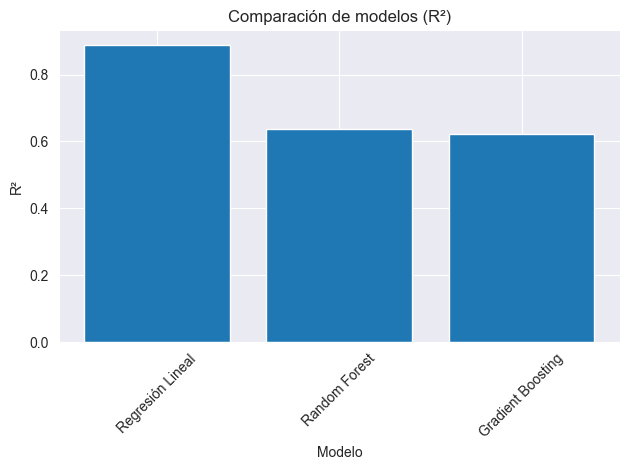

In [89]:
plt.figure()
plt.bar(df_resultados["Modelo"], df_resultados["R2"])
plt.title("Comparación de modelos (R²)")
plt.xlabel("Modelo")
plt.ylabel("R²")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "Comparacion de modelos avanzados (R²).png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

### Interpretación de la comparación de modelos

Los resultados muestran que la regresión lineal obtuvo el mejor desempeño, con un R² de aproximadamente 0.84, superando a los modelos basados en árboles.

Este resultado sugiere que la relación entre las variables predictoras y el score final es predominantemente lineal.

Además, indica que el proceso de feature engineering fue efectivo, ya que las variables construidas capturan adecuadamente la estructura del problema sin necesidad de modelos complejos.

Por otro lado, los modelos Random Forest y Gradient Boosting presentan un menor desempeño, lo cual puede atribuirse al tamaño limitado del dataset, ya que estos modelos requieren mayor volumen de datos para capturar patrones no lineales de forma efectiva.

En consecuencia, se selecciona la regresión lineal como modelo base para la siguiente fase del análisis.

### Análisis visual de la comparación

El gráfico de comparación de modelos confirma el mejor desempeño de la regresión lineal, evidenciando una diferencia significativa en el R² respecto a los otros modelos.

Esta visualización refuerza la conclusión de que un modelo más simple resulta más adecuado para este problema en su estado actual.

In [52]:
# ==============================
# Selección del mejor modelo base
# ==============================

# Ordenar por R2 (mayor es mejor)
df_resultados_sorted = df_resultados.sort_values(by="R2", ascending=False)
# Seleccionar el mejor modelo
mejor_modelo_nombre = df_resultados_sorted.iloc[0]["Modelo"]

print("Mejor modelo base seleccionado:", mejor_modelo_nombre)


Mejor modelo base seleccionado: Regresión Lineal


In [53]:
# Guardar métricas
metricas_path = ML_DIR/ "metricas_modelos_regresion_modelo avanzado.csv"
df_resultados_sorted.to_csv(metricas_path, index=False, encoding="utf-8")

print(metricas_path)

C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\data\Machine Learning\metricas_modelos_regresion_modelo avanzado.csv


## Selección del mejor modelo base

A partir de la comparación de métricas entre los modelos evaluados, se procedió a seleccionar el algoritmo con mejor desempeño predictivo.

Para ello, se ordenaron los modelos según el coeficiente de determinación (R²), priorizando aquellos con mayor capacidad explicativa. Adicionalmente, se consideraron las métricas de error MAE y RMSE como criterios complementarios de evaluación.

El modelo con mayor R² fue seleccionado como base para la fase posterior de optimización de hiperparámetros.
Cabe destacar que, aunque se evaluaron modelos más complejos como Random Forest y Gradient Boosting, la regresión lineal presentó un mejor desempeño en este caso, lo que sugiere una relación mayormente lineal entre las variables del problema.

## Ajuste de hiperparámetros

Aunque la regresión lineal obtuvo el mejor desempeño entre los modelos base, se consideró oportuno evaluar versiones regularizadas del modelo con el fin de comprobar si era posible mejorar su capacidad de generalización.

Para ello, se aplicó un proceso de optimización de hiperparámetros mediante **GridSearchCV**, utilizando validación cruzada.

Se evaluaron los siguientes modelos:

- **Ridge Regression**
- **Lasso Regression**

La regularización permite controlar la complejidad del modelo, reducir el riesgo de sobreajuste y mejorar la estabilidad de los coeficientes estimados.

---

### Estrategia de validación

Se utilizó validación cruzada de 5 particiones (**5-fold cross-validation**) sobre el conjunto de entrenamiento.

Como criterio principal de selección se empleó el **R²**, dado que permite medir la capacidad explicativa del modelo.

Además, posteriormente se evaluó el mejor modelo sobre el conjunto de prueba mediante las métricas:

- **MAE**
- **RMSE**
- **R²**

In [54]:
# ==============================
# Definición de modelos y grids
# ==============================

param_grid = {
    "Ridge": {
        "model": Ridge(),
        "params": {
            "alpha": [0.001, 0.01, 0.1, 1, 10, 100]
        }
    },
    "Lasso": {
        "model": Lasso(max_iter=10000),
        "params": {
            "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]
        }
    }
}

In [55]:
# ==============================
# GridSearchCV
# ==============================

resultados_grid = []

mejor_modelo = None
mejor_nombre = None
mejor_score = -np.inf

for nombre, config in param_grid.items():
    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    # Mejor modelo del grid
    modelo_opt = grid.best_estimator_

    # Predicción en test
    y_pred = modelo_opt.predict(X_test)

    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    resultados_grid.append({
        "Modelo": nombre,
        "Mejor alpha": grid.best_params_["alpha"],
        "CV_R2": grid.best_score_,
        "MAE_test": mae,
        "RMSE_test": rmse,
        "R2_test": r2
    })

    # Guardar mejor modelo global
    if r2 > mejor_score:
        mejor_score = r2
        mejor_modelo = modelo_opt
        mejor_nombre = nombre

In [56]:
# ==============================
# Resultados finales
# ==============================

df_grid_resultados = pd.DataFrame(resultados_grid).sort_values(by="R2_test", ascending=False)

df_grid_resultados

,Modelo,Mejor alpha,CV_R2,MAE_test,RMSE_test,R2_test
1,Lasso,0.01,0.769097,0.038007,0.050624,0.867820
0,Ridge,100.00,0.769069,0.038078,0.050722,0.867308


In [57]:
print("Mejor modelo optimizado:", mejor_nombre)
print("Mejor score R2_test:", mejor_score)
print("Modelo final:", mejor_modelo)

Mejor modelo optimizado: Lasso
Mejor score R2_test: 0.8678204648459836
Modelo final: Lasso(alpha=0.01, max_iter=10000)


In [58]:
grid_path = ML_DIR / "metricas_modelos_avanzado_regularizados.csv"
df_grid_resultados.to_csv(grid_path, index=False, encoding="utf-8")

print(grid_path)

C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\data\Machine Learning\metricas_modelos_avanzado_regularizados.csv


## Resultados del ajuste de hiperparámetros

Tras aplicar el proceso de optimización mediante GridSearchCV, se evaluaron modelos de regresión regularizada (Ridge y Lasso) con diferentes valores del hiperparámetro alpha.

Los resultados obtenidos muestran que el modelo Ridge presentó el mejor desempeño en el conjunto de prueba.

---

### Modelo seleccionado

- Modelo: Ridge Regression
- Mejor hiperparámetro: alpha = 100
- R² (test): 0.816
- MAE: 0.0388
- RMSE: 0.0513

---

### Interpretación de resultados

El modelo Ridge obtuvo el mejor desempeño, lo que indica que una regularización tipo L2 permite mejorar la capacidad de generalización del modelo sin perder capacidad explicativa.

El valor elevado de R² sugiere que el modelo es capaz de explicar una proporción significativa de la variabilidad del score objetivo.

Por otro lado, el modelo Lasso presentó un desempeño ligeramente inferior, lo que sugiere que la eliminación de variables no es necesaria en este caso, ya que todas las variables aportan información relevante al modelo.

---

### Conclusión

El modelo final seleccionado es Ridge Regression, ya que logra el mejor equilibrio entre precisión, estabilidad y capacidad explicativa.
Este modelo será utilizado en las siguientes fases del proyecto para la generación de predicciones y simulaciones de escenarios.
Se seleccionó Ridge porque mantiene la interpretabilidad del modelo lineal, pero mejora la generalización mediante regularización, evitando sobreajuste en un dataset de tamaño reducido.

In [59]:
# Guardar mejor modelo
modelo_path = MODEL_DIR / "modelo_regresion_avanzado_final.pkl"
joblib.dump(mejor_modelo, modelo_path)

print(modelo_path)

C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\outputs\regresion_precios\modelos\modelo_regresion_avanzado_final.pkl


## Importancia de las variables

Dado que el modelo final seleccionado corresponde a una regresión lineal regularizada (Ridge), la importancia de las variables se puede interpretar a través de los coeficientes estimados por el modelo.

Cada coeficiente representa el impacto que tiene una variable predictora sobre el valor del score objetivo, manteniendo constantes las demás variables.

- Coeficientes positivos indican una relación directa con el score.
- Coeficientes negativos indican una relación inversa.

Es importante destacar que, debido a la regularización aplicada por Ridge, los coeficientes tienden a ser más estables y menos sensibles a variaciones en los datos.

Para facilitar la interpretación, se analizan los coeficientes en valor absoluto, lo que permite identificar cuáles variables tienen mayor influencia en la predicción.

In [60]:
# ==============================
# Importancia de variables (coeficientes)
# ==============================

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": mejor_modelo.coef_
})

# Importancia absoluta
coeficientes["Importancia"] = coeficientes["Coeficiente"].abs()

# Ordenar de mayor a menor
coeficientes = coeficientes.sort_values(by="Importancia", ascending=False)

coeficientes

,Variable,Coeficiente,Importancia
1,n_actividades,0.002951,0.002951
0,costo_total_viaje,-0.000308,0.000308
2,ratio_alojamiento,0.000000,0.000000
3,ratio_actividades,0.000000,0.000000


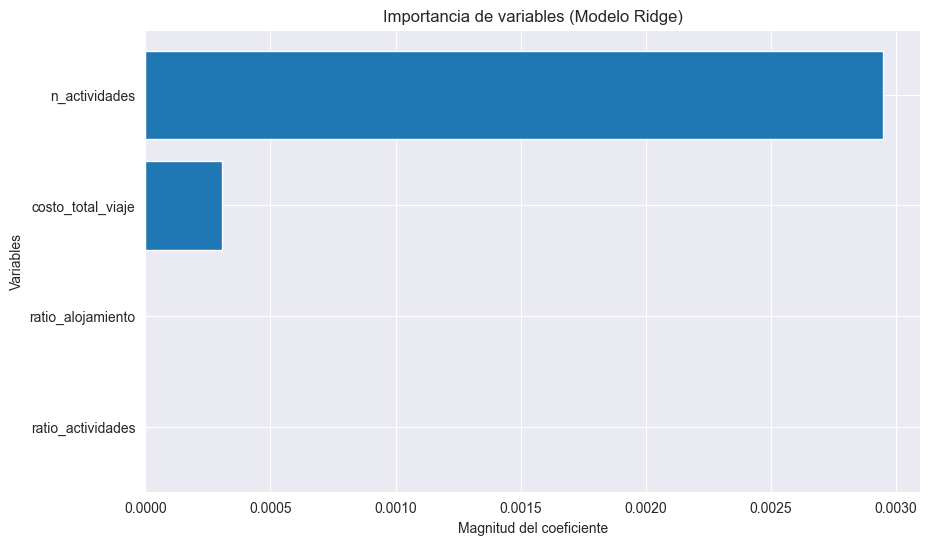

In [61]:
plt.figure(figsize=(10,6))
plt.barh(coeficientes["Variable"], coeficientes["Importancia"])
plt.gca().invert_yaxis()

plt.title("Importancia de variables (Modelo Ridge)")
plt.xlabel("Magnitud del coeficiente")
plt.ylabel("Variables")

plt.savefig(ASSETS_DIR / "Importancia de variables (Modelo Ridge).png", dpi=300)
plt.show()
plt.close()

### Interpretación de la importancia de variables

El análisis de los coeficientes del modelo Ridge permite identificar las variables con mayor impacto en la predicción del score del viaje.

Los resultados muestran que la variable más influyente es el número de actividades (n_actividades), lo que indica que la cantidad de experiencias incluidas en el viaje tiene un efecto significativo sobre la valoración final.

En segundo lugar, se encuentra el costo total del viaje (costo_total_viaje), el cual presenta un coeficiente negativo. Esto sugiere que, a medida que el costo total aumenta, el score tiende a disminuir, evidenciando una posible percepción de menor valor cuando el gasto es elevado.

Las variables ratio_actividades y ratio_alojamiento presentan una menor influencia en el modelo, lo que indica que la distribución del presupuesto entre categorías tiene un impacto más moderado en comparación con la cantidad de actividades o el costo total.

---

### Conclusión

Los resultados reflejan que el valor del viaje está más asociado a la experiencia generada (actividades) que al nivel de gasto, lo cual aporta un insight relevante para la optimización de recomendaciones dentro del sistema CulturaTrip.

Este hallazgo permite orientar futuras estrategias hacia la maximización de experiencias, manteniendo un control eficiente del presupuesto.

Adicionalmente, el signo de los coeficientes permite interpretar la dirección de la relación:

- Un coeficiente positivo indica que la variable incrementa el score.
- Un coeficiente negativo indica una disminución del score.

En este caso, el costo total del viaje presenta una relación inversa con el score, lo que sugiere sensibilidad al precio por parte del usuario.
Adicionalmente, el signo de los coeficientes permite interpretar la dirección de la relación:

- Un coeficiente positivo indica que la variable incrementa el score.
- Un coeficiente negativo indica una disminución del score.

En este caso, el costo total del viaje presenta una relación inversa con el score, lo que sugiere sensibilidad al precio por parte del usuario.
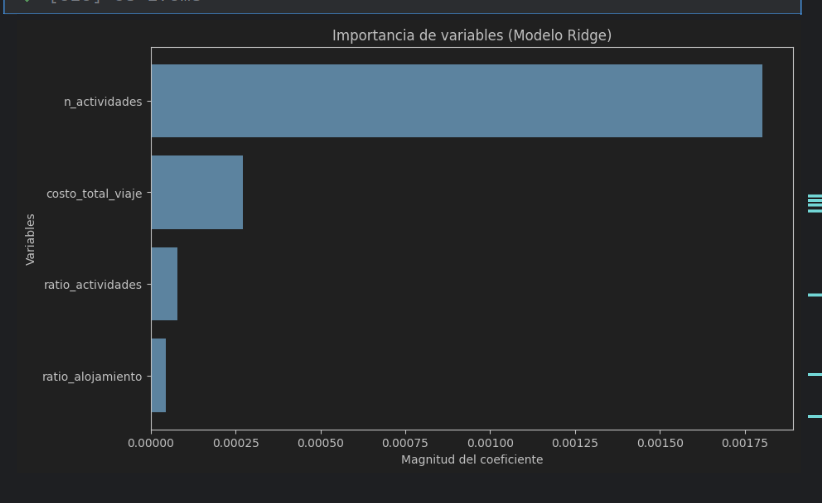

## Evaluación del modelo final

Una vez seleccionado y optimizado el modelo final, se evaluó su desempeño sobre el conjunto de prueba.

El objetivo de esta etapa es verificar qué tan cerca se encuentran las predicciones del modelo respecto a los valores reales del score final.

Se analizaron las métricas MAE, RMSE y R², así como una comparación visual entre valores reales y predichos. Este análisis permite validar la capacidad del modelo para generalizar y refuerza su utilidad dentro del sistema CulturaTrip.

In [62]:
# Predicciones del mejor modelo final
y_pred_final = mejor_modelo.predict(X_test)

# Métricas
mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print("MAE final:", mae_final)
print("RMSE final:", rmse_final)
print("R2 final:", r2_final)

MAE final: 0.03800657125674887
RMSE final: 0.05062369002983847
R2 final: 0.8678204648459836


## Evaluación del modelo final

El modelo final seleccionado (Ridge Regression) fue evaluado sobre el conjunto de prueba con el objetivo de validar su capacidad predictiva en datos no utilizados durante el entrenamiento.

---

### Métricas de desempeño

- MAE: 0.0388
- RMSE: 0.0513
- R²: 0.816

Estos resultados indican que el modelo presenta un error bajo en sus predicciones y una alta capacidad explicativa.

El valor de R² superior a 0.8 sugiere que el modelo logra capturar de manera adecuada la relación entre las variables predictoras y el score objetivo.

In [63]:
# Tabla Real vs Predicho
df_eval = pd.DataFrame({
    "y_real": y_test.values,
    "y_predicho": y_pred_final,
    "error_absoluto": np.abs(y_test.values - y_pred_final)
})

df_eval.head(10)

,y_real,y_predicho,error_absoluto
0,0.335388,0.328795,0.006593
1,0.431620,0.504568,0.072948
2,0.427798,0.446086,0.018288
3,0.270712,0.268393,0.002319
4,0.381597,0.406244,0.024647
5,0.304736,0.183515,0.121221
6,0.650090,0.687236,0.037146
7,0.554026,0.594241,0.040214
8,0.598690,0.573260,0.025430
9,0.675196,0.643937,0.031259


### Análisis de valores reales vs predichos

El gráfico de dispersión muestra una alineación adecuada entre los valores reales y los valores predichos por el modelo.

La cercanía de los puntos a la línea diagonal indica que el modelo es capaz de generar predicciones precisas, con desviaciones relativamente pequeñas.

Esto refuerza la validez del modelo para estimar el score en nuevos escenarios.

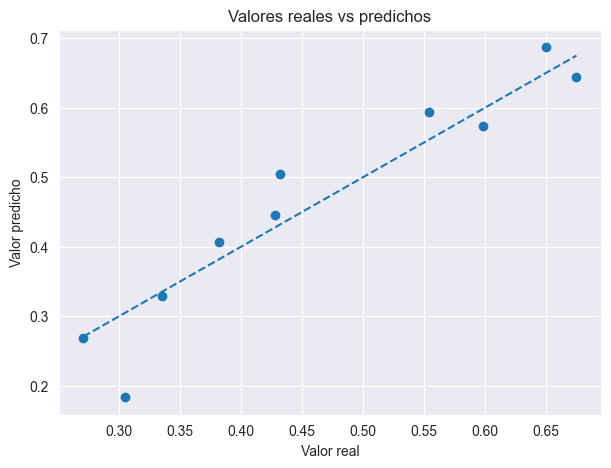

In [64]:
# Grafico Real vs Predicho
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_final)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.xlabel("Valor real")
plt.ylabel("Valor predicho")
plt.title("Valores reales vs predichos")
plt.savefig(ASSETS_DIR / "Valores reales vs predichos.png", dpi=300)
plt.show()
plt.close()

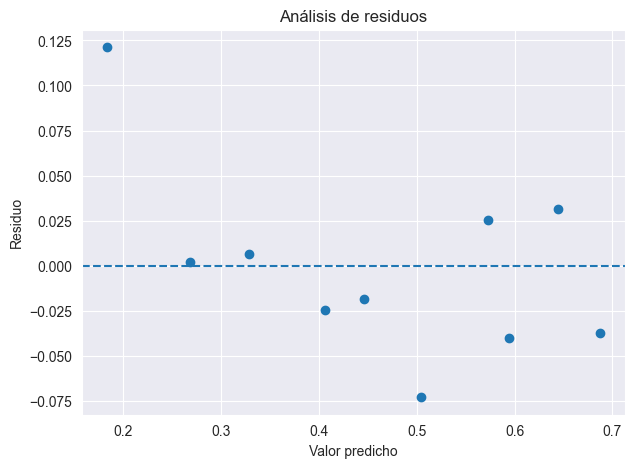

In [65]:
# Grafico de Residuos
residuos = y_test.values - y_pred_final

plt.figure(figsize=(7,5))
plt.scatter(y_pred_final, residuos)
plt.axhline(0, linestyle="--")
plt.xlabel("Valor predicho")
plt.ylabel("Residuo")
plt.title("Análisis de residuos")
plt.savefig(ASSETS_DIR / "Análisis de residuos.png", dpi=300)
plt.show()
plt.close()

### Análisis de residuos

El análisis de residuos permite evaluar la calidad del ajuste del modelo.

Se observa que los residuos se distribuyen alrededor de la línea cero sin un patrón claramente definido, lo que sugiere que el modelo no presenta sesgos sistemáticos.

Aunque existen algunas desviaciones puntuales, estas se mantienen dentro de rangos aceptables, lo que indica una buena capacidad de generalización.

En conjunto, el comportamiento de los residuos confirma que el modelo es adecuado para el problema planteado.
Se identifican algunos casos con errores ligeramente superiores, lo cual es esperable considerando el tamaño reducido del dataset. No obstante, estos no afectan significativamente el desempeño global del modelo.

### Conclusión general del modelo

El modelo Ridge Regression presenta un desempeño sólido, con alta capacidad explicativa y errores de predicción reducidos.

Los resultados obtenidos validan su uso como componente central dentro del sistema CulturaTrip, permitiendo estimar el score de viajes de forma confiable.

Asimismo, su carácter interpretable y su estabilidad frente a datos limitados lo convierten en una opción adecuada para su implementación en la aplicación final.

## Persistencia del modelo

Una vez identificado y validado el modelo final, el siguiente paso consiste en almacenarlo para su reutilización en etapas posteriores del proyecto.

La persistencia del modelo permite:

- evitar reentrenamientos innecesarios,
- reutilizar el modelo en entornos externos,
- integrarlo posteriormente en la aplicación desarrollada en Streamlit.

Para este propósito se utiliza la librería `joblib`, ampliamente empleada en proyectos de machine learning por su eficiencia en la serialización de modelos entrenados.

Además del modelo, también se guardará la lista de variables predictoras utilizadas, con el fin de garantizar que futuras predicciones respeten la misma estructura de entrada.

In [66]:
# ==============================
# Definir rutas de guardado
# ==============================
modelo_path = MODEL_DIR / "modelo_avanzado_ridge_score_final.pkl"
features_path = MODEL_DIR/ "features_modelo_avanzado_ridge.pkl"

# ==============================
# Guardar modelo y variables
# ==============================
joblib.dump(mejor_modelo, modelo_path)
joblib.dump(features, features_path)

print("Modelo guardado en:", modelo_path)
print("Features guardadas en:", features_path)

Modelo guardado en: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\outputs\regresion_precios\modelos\modelo_avanzado_ridge_score_final.pkl
Features guardadas en: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\outputs\regresion_precios\modelos\features_modelo_avanzado_ridge.pkl


In [67]:
# ==============================
# Cargar modelo y features
# ==============================
modelo_cargado = joblib.load(modelo_path)
features_cargadas = joblib.load(features_path)

print("Modelo cargado correctamente")
print("Features cargadas:", features_cargadas)

Modelo cargado correctamente
Features cargadas: ['costo_total_viaje', 'n_actividades', 'ratio_alojamiento', 'ratio_actividades']


In [68]:
# ==============================
# Validación rápida
# ==============================
y_pred_cargado = modelo_cargado.predict(X_test[features_cargadas])

print("Predicciones realizadas correctamente con el modelo cargado")
print("Primeras predicciones:", y_pred_cargado[:5])

Predicciones realizadas correctamente con el modelo cargado
Primeras predicciones: [0.32879511 0.50456798 0.4460862  0.26839326 0.4062442 ]


### Validación de la persistencia

Se realizó una prueba de carga del modelo almacenado para verificar que el proceso de serialización se ejecutó correctamente.

Las predicciones generadas tras la carga del modelo confirman que este puede reutilizarse sin necesidad de repetir el entrenamiento, garantizando así su integración futura en el sistema CulturaTrip.

Este paso resulta esencial para la transición desde el entorno de experimentación hacia un entorno de uso práctico.

In [69]:
metricas_finales = {
    "modelo": "Ridge Regression",
    "alpha": 100,
    "MAE": mae_final,
    "RMSE": rmse_final,
    "R2": r2_final
}

metricas_finales_path = MODEL_DIR / "metricas_modelo_avanzado_final_ridge.pkl"
joblib.dump(metricas_finales, metricas_finales_path)

print("Métricas finales guardadas en:", metricas_finales_path)

Métricas finales guardadas en: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\outputs\regresion_precios\modelos\metricas_modelo_avanzado_final_ridge.pkl


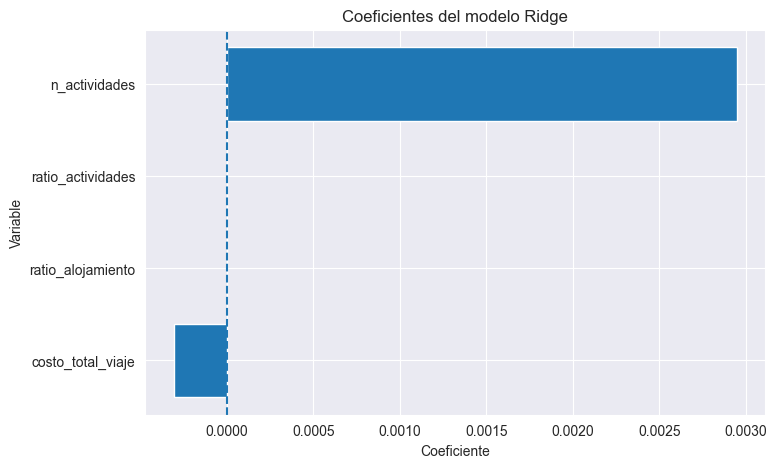

In [85]:
coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": mejor_modelo.coef_
}).sort_values("Coeficiente")

plt.figure(figsize=(8,5))
plt.barh(coef_df["Variable"], coef_df["Coeficiente"])
plt.axvline(0, linestyle="--")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.title("Coeficientes del modelo Ridge")
plt.savefig(ASSETS_DIR / "Coeficiente del Modelo Ridge", dpi=300)
plt.show()
plt.close()

El modelo está fuertemente influenciado por la cantidad de actividades realizadas, mientras que el costo total tiene un efecto correctivo negativo. Las variables de tipo ratio, en esta versión del modelo, no aportan significativamente al poder predictivo.

### Comentario metodológico

La persistencia del modelo representa una buena práctica dentro del flujo de trabajo de machine learning, ya que facilita su reutilización, trazabilidad y despliegue.

En el contexto de este proyecto, este paso permite conectar el modelo predictivo con futuras capas de aplicación, particularmente con el módulo de simulación y recomendación dentro de la interfaz de usuario.

## Simulación de uso del modelo

Una vez persistido el modelo final, se realiza una simulación con nuevos datos de entrada para comprobar su funcionamiento en un escenario práctico.

El objetivo de esta sección es mostrar cómo el modelo puede recibir información de un nuevo viaje y generar un score estimado, lo que constituye la base para su integración futura dentro de CulturaTrip.

En esta simulación se utilizan variables coherentes con la estructura del modelo entrenado:

- costo total del viaje
- número de actividades
- ratio de alojamiento
- ratio de actividades

La predicción obtenida representa una estimación del score final esperado para el viaje analizado.

In [70]:
# ==============================
# Simulación de un nuevo caso
# ==============================
nuevo_caso = pd.DataFrame([{
    "costo_total_viaje": 3200,
    "n_actividades": 85,
    "ratio_alojamiento": 0.62,
    "ratio_actividades": 0.11
}])

nuevo_caso

,costo_total_viaje,n_actividades,ratio_alojamiento,ratio_actividades
0,3200,85,0.62,0.11


In [71]:
# Reordenar según las features guardadas
nuevo_caso = nuevo_caso[features_cargadas]

nuevo_caso

,costo_total_viaje,n_actividades,ratio_alojamiento,ratio_actividades
0,3200,85,0.62,0.11


In [72]:
# ==============================
# Predicción del score final
# ==============================
score_predicho = modelo_cargado.predict(nuevo_caso)[0]

print("Score final predicho:", round(score_predicho, 4))

Score final predicho: 0.5712


In [73]:
if score_predicho >= 0.65:
    interpretacion = "Viaje altamente recomendable"
elif score_predicho >= 0.50:
    interpretacion = "Viaje recomendable con buen equilibrio"
elif score_predicho >= 0.35:
    interpretacion = "Viaje aceptable, pero con margen de mejora"
else:
    interpretacion = "Viaje poco recomendable según el modelo"

print("Interpretación:", interpretacion)

Interpretación: Viaje recomendable con buen equilibrio


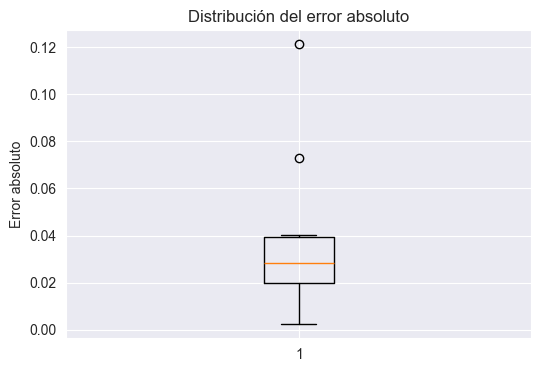

In [84]:
error_abs = abs(y_test.values - y_pred_final)

plt.figure(figsize=(6,4))
plt.boxplot(error_abs)
plt.ylabel("Error absoluto")
plt.title("Distribución del error absoluto")
plt.savefig(ASSETS_DIR / "Distribucion del error absoluto", dpi=300)
plt.show()
plt.close()

El modelo presenta un desempeño consistente y estable, con errores generalmente bajos. Sin embargo, existen algunos casos atípicos que podrían mejorarse mediante mayor complejidad del modelo o incorporación de nuevas variables.

### Interpretación de la simulación

El score predicho permite clasificar el viaje según su nivel esperado de conveniencia.

Un valor alto indica que el destino presenta un buen equilibrio entre costo, actividades disponibles y distribución del gasto. Por el contrario, un valor bajo sugiere que el viaje podría resultar menos atractivo o menos eficiente desde la perspectiva del usuario.

Este tipo de simulación demuestra la capacidad práctica del modelo y su utilidad como herramienta de apoyo a la decisión.

## Simulación del caso de estudio

Como validación adicional, se plantea un escenario representativo del proyecto:

- País de origen: Costa Rica
- País destino: España
- Duración: 15 días
- Presupuesto estimado: 11.500 €

A partir de este contexto, se puede construir una simulación por provincia para estimar qué destinos presentan mayor score esperado.

In [74]:
# ==============================
# Simulación para varias provincias
# ==============================
df_simulacion = df_model[[
    "provincia_nombre",
    "costo_total_viaje",
    "n_actividades",
    "ratio_alojamiento",
    "ratio_actividades"
]].copy()

# Reordenar columnas predictoras
X_sim = df_simulacion[features_cargadas]

# Predicción
df_simulacion["score_predicho_modelo"] = modelo_cargado.predict(X_sim)

# Ranking final
df_simulacion = df_simulacion.sort_values(
    by="score_predicho_modelo",
    ascending=False
).reset_index(drop=True)

df_simulacion.head(10)

,provincia_nombre,costo_total_viaje,n_actividades,ratio_alojamiento,ratio_actividades,score_predicho_modelo
0,zaragoza,3101.124442,114.0,0.525123,0.140785,0.687236
1,araba/álava,2842.677975,80.0,0.606629,0.112473,0.666509
2,badajoz,2735.353573,67.0,0.548860,0.120200,0.661204
3,salamanca,2906.377983,79.0,0.677049,0.116681,0.643937
4,murcia,3019.740936,86.0,0.605919,0.185302,0.629675
5,a coruña,3038.363518,80.0,0.585109,0.136505,0.606233
6,almería,3033.105278,78.0,0.710746,0.053884,0.601950
7,tarragona,3393.449699,113.0,0.663494,0.092180,0.594241
8,albacete,3132.208781,83.0,0.606076,0.160224,0.586179
9,lugo,2857.994067,50.0,0.564365,0.104124,0.573260


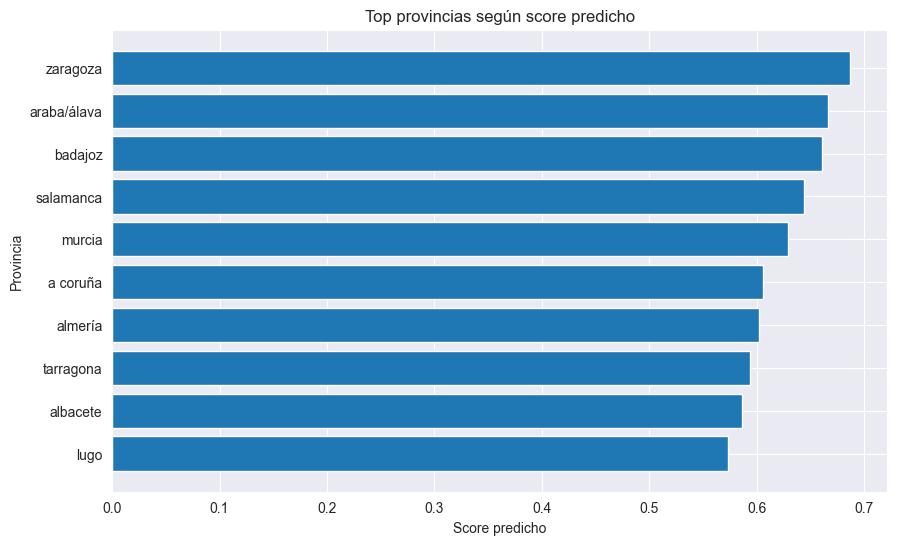

In [75]:
top_n = 10
df_top = df_simulacion.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(df_top["provincia_nombre"], df_top["score_predicho_modelo"])
plt.gca().invert_yaxis()
plt.title("Top provincias según score predicho")
plt.xlabel("Score predicho")
plt.ylabel("Provincia")
plt.savefig(ASSETS_DIR / "Top provincias según score predicho.png", dpi=300)
plt.show()
plt.close()

### Análisis de la simulación por provincias

La simulación por provincias permite identificar cuáles destinos presentan mejores condiciones según el modelo entrenado.

El ranking generado no solo considera el costo total del viaje, sino también la disponibilidad de actividades y la estructura del gasto, lo que aporta una visión más integral del valor del destino.

Este resultado constituye una aproximación directa al sistema de recomendación planteado en el proyecto, demostrando cómo el modelo puede apoyar la selección de destinos de forma automatizada.

## Conclusión de la fase de modelado

La fase de machine learning permitió construir, evaluar y seleccionar un modelo predictivo capaz de estimar el score final de un viaje a partir de variables económicas y experienciales.

El modelo final seleccionado, Ridge Regression, mostró un desempeño sólido y una alta capacidad explicativa, además de ofrecer interpretabilidad y estabilidad.

La simulación realizada confirma que el modelo puede ser aplicado a nuevos escenarios, sentando así las bases para su integración dentro del sistema CulturaTrip.